# Classifier Baseline

Baseline pipeline for Random Forest earthquake classification with configurable threshold strategy on test metrics.

## 1) Setup

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

from src.utils.runtime_utils import resolve_project_root

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data_rf
from config.config_loader import load_rf_config
from src.utils.metrics import (
    classification_metrics,
    plot_and_save_pr_curve,
    plot_and_save_confusion_matrix,
)
from src.utils.bootstrap_ci import (
    SamplingMethod,
    bootstrap_multi_model_curve_ci,
    resolve_seed_checkpoint_paths,
)
from src.utils.classifier_compare_utils import (
    build_rf_em_window_ci_cache,
    render_classification_bootstrap_export,
    ensure_identical_labels,
    load_npz_prediction_cache,
    mean_seed_metrics,
    mf_token,
    paired_metric_bootstrap,
    run_classification_bootstrap_export_pipeline,
    round_optional,
    save_npz_prediction_cache,
    summarize_classification_metric_rows,
)
from src.utils.bootstrap_presets import PairedBootstrapPreset

print(f'PROJECT_ROOT: {PROJECT_ROOT}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Config

In [2]:
args = load_rf_config(PROJECT_ROOT)
BASE_DIR = PROJECT_ROOT / 'data' / args.dataset
print(f'Dataset: {args.dataset}')
NOTEBOOK_NAME = 'classifier_baseline'
FIG_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME/args.t_elaps_mode
METRIC_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / NOTEBOOK_NAME / args.t_elaps_mode
CACHE_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'cache' / NOTEBOOK_NAME / args.t_elaps_mode
FIG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figure export dir: {FIG_EXPORT_DIR}')
print(f'Metric export dir: {METRIC_EXPORT_DIR}')

# Multi-seed RF settings (for window comparison / export)
RF_MULTI_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7]
RF_SEED_AGG_METHOD = 'mean'  # seed-wise mean for ROC/PR plotting
RF_PRED_CACHE_ENABLED = True
RF_PRED_CACHE_DIR = CACHE_EXPORT_DIR / 'rf_multi_seed_predictions'
RF_FORCE_RETRAIN = False

# Export point metrics are mean of seed-wise metrics
EXPORT_POINT_METRIC_MODE = 'mean_seed_metrics'
BOOTSTRAP_POINT_ESTIMATE_MODE = 'mean'  # seed-wise mean

# CI mode: include both seed + sample variability when True
USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP = True
BOOTSTRAP_SELECTED_SEEDS = None  # e.g., [0, 2]; None => use all available/configured seeds
BOOTSTRAP_SELECTED_SEED_SET = (
    {int(seed) for seed in BOOTSTRAP_SELECTED_SEEDS}
    if BOOTSTRAP_SELECTED_SEEDS is not None
    else None
)
RF_BOOTSTRAP_SEEDS = [
    int(seed)
    for seed in RF_MULTI_SEEDS
    if BOOTSTRAP_SELECTED_SEED_SET is None or int(seed) in BOOTSTRAP_SELECTED_SEED_SET
]
if len(RF_BOOTSTRAP_SEEDS) == 0:
    raise ValueError('No RF seeds selected. Check BOOTSTRAP_SELECTED_SEEDS and RF_MULTI_SEEDS.')

print('RF multi seeds:', RF_MULTI_SEEDS)
print('RF seed aggregation (for curves):', RF_SEED_AGG_METHOD)
print('RF pred cache enabled:', RF_PRED_CACHE_ENABLED)
print('RF pred cache dir:', RF_PRED_CACHE_DIR)
print('RF force retrain:', RF_FORCE_RETRAIN)
print('Export point metric mode:', EXPORT_POINT_METRIC_MODE)
print('Bootstrap point estimate mode:', BOOTSTRAP_POINT_ESTIMATE_MODE)
print('Use hierarchical seed+sample bootstrap:', USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP)
print('Selected bootstrap seeds:', BOOTSTRAP_SELECTED_SEEDS)
print('Effective RF bootstrap seeds:', RF_BOOTSTRAP_SEEDS)


Dataset: ChuanDian
Figure export dir: /root/autodl-tmp/em_eqf/notebooks/figs/classifier_baseline/global
Metric export dir: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/global
RF multi seeds: [0, 1, 2, 3, 4, 5, 6, 7]
RF seed aggregation (for curves): mean
RF pred cache enabled: True
RF pred cache dir: /root/autodl-tmp/em_eqf/notebooks/cache/classifier_baseline/global/rf_multi_seed_predictions
RF force retrain: False
Export point metric mode: mean_seed_metrics
Bootstrap point estimate mode: mean
Use hierarchical seed+sample bootstrap: True
Selected bootstrap seeds: None
Effective RF bootstrap seeds: [0, 1, 2, 3, 4, 5, 6, 7]


In [3]:
args.t_elaps_mode

'global'

## 3) Data Preparation

In [4]:
df, features_df, x_train, x_val, x_test, y_train, y_val, y_test = prepare_data_rf(args, BASE_DIR)

print(f'features_df columns: {len(features_df.columns)}')
print(f"Mag_max mean: {features_df['Mag_max'].mean():.4f}")

[Train] positive: 390 | negative: 830 | total: 1220
[Train] positive ratio: 0.320 | negative ratio: 0.680
[Validation] positive: 62 | negative: 90 | total: 152
[Validation] positive ratio: 0.408 | negative ratio: 0.592
[Test] positive: 19 | negative: 135 | total: 154
[Test] positive ratio: 0.123 | negative ratio: 0.877
features_df columns: 23
Mag_max mean: 5.3123


In [5]:
np.isnan(x_train).any(), np.isnan(x_val).any(), np.isnan(x_test).any()

(np.False_, np.False_, np.False_)

## 4) Train Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=50,
    class_weight='balanced',
)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=50)

## 5) ROC Curve

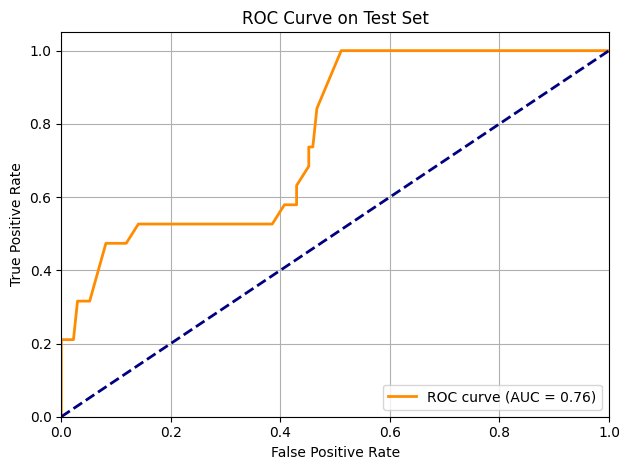

In [7]:
y_prob = rf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
# plt.savefig(FIG_EXPORT_DIR / 'roc_curve.pdf')
plt.show()

## 6) Metrics With Threshold Switch


Validation metrics:
{'precision': 0.7215189873417721, 'recall': 0.9193548387096774, 'f1': 0.8085106382978723, 'auc': 0.9086021505376344, 'pr_auc': 0.8681962430011485, 'fpr': 0.24444444444444444, 'tpr': 0.9193548387096774, 'R': 0.6749103942652329, 'conf': 1.0, 'threshold': 0.3}

Test metrics:
{'precision': 0.4090909090909091, 'recall': 0.47368421052631576, 'f1': 0.43902439024390244, 'auc': 0.7635477582846004, 'pr_auc': 0.4547086164617174, 'fpr': 0.0962962962962963, 'tpr': 0.47368421052631576, 'R': 0.3773879142300195, 'conf': 1.0, 'threshold': 0.53, 'threshold_mode': 'auto', 'val_threshold': 0.3}


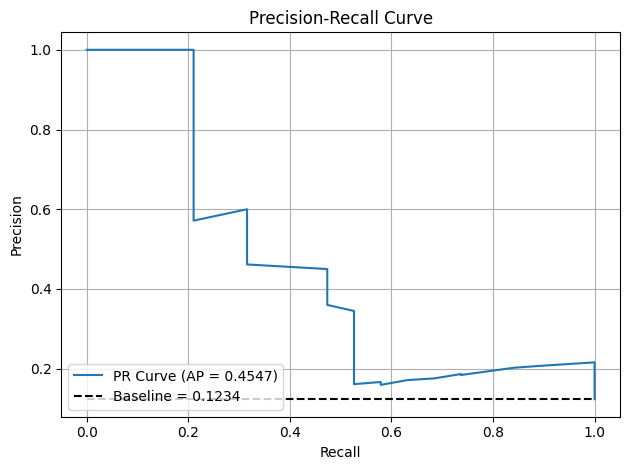

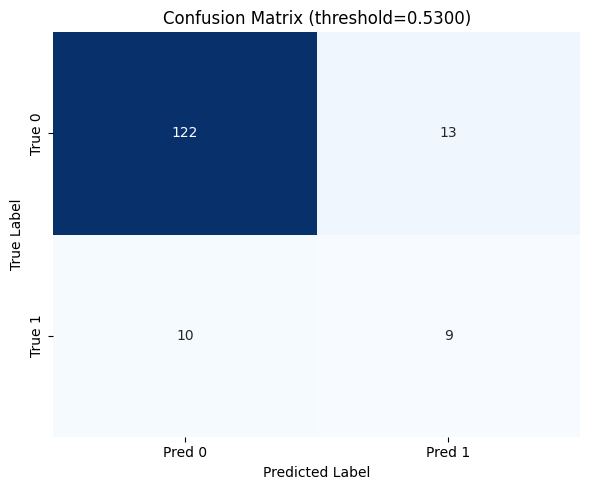

In [8]:
# For RF probabilities, keep apply_sigmoid=False.
# Supported modes:
# - 'auto'          : same as classification_metrics(y_test, y_prob)
# - 'val_threshold' : same as classification_metrics(y_test, y_prob, val_metrics['threshold'])
TEST_THRESHOLD_MODE = 'auto'  # 'auto' | 'val_threshold'

y_val_prob = rf.predict_proba(x_val)[:, 1]
val_metrics = classification_metrics(y_val, y_val_prob, apply_sigmoid=False)

if TEST_THRESHOLD_MODE == 'auto':
    # test_metrics = classification_metrics(y_test, y_prob)
    test_metrics = classification_metrics(y_test, y_prob, apply_sigmoid=False)
elif TEST_THRESHOLD_MODE == 'val_threshold':
    # test_metrics = classification_metrics(y_test, y_prob, val_metrics['threshold'])
    test_metrics = classification_metrics(
        y_test,
        y_prob,
        threshold=val_metrics['threshold'],
        apply_sigmoid=False,
    )
else:
    raise ValueError(f'Unknown TEST_THRESHOLD_MODE: {TEST_THRESHOLD_MODE}')

test_metrics['threshold_mode'] = TEST_THRESHOLD_MODE
test_metrics['val_threshold'] = float(val_metrics['threshold'])

print('Validation metrics:')
print(val_metrics)
print()
print('Test metrics:')
print(test_metrics)

plot_and_save_pr_curve(
    y_test,
    y_prob,
    pr_auc_value=float(test_metrics['pr_auc']),
    save_dir=str(FIG_EXPORT_DIR),
    # filename='pr_curve.pdf',
)

plot_and_save_confusion_matrix(
    y_test,
    y_prob,
    threshold=float(test_metrics['threshold']),
    save_dir=str(FIG_EXPORT_DIR),
    # filename='confusion_matrix.pdf',
    apply_sigmoid=False,
)


In [9]:
test_metrics

{'precision': 0.4090909090909091,
 'recall': 0.47368421052631576,
 'f1': 0.43902439024390244,
 'auc': 0.7635477582846004,
 'pr_auc': 0.4547086164617174,
 'fpr': 0.0962962962962963,
 'tpr': 0.47368421052631576,
 'R': 0.3773879142300195,
 'conf': 1.0,
 'threshold': 0.53,
 'threshold_mode': 'auto',
 'val_threshold': 0.3}

## 7) Feature Importance


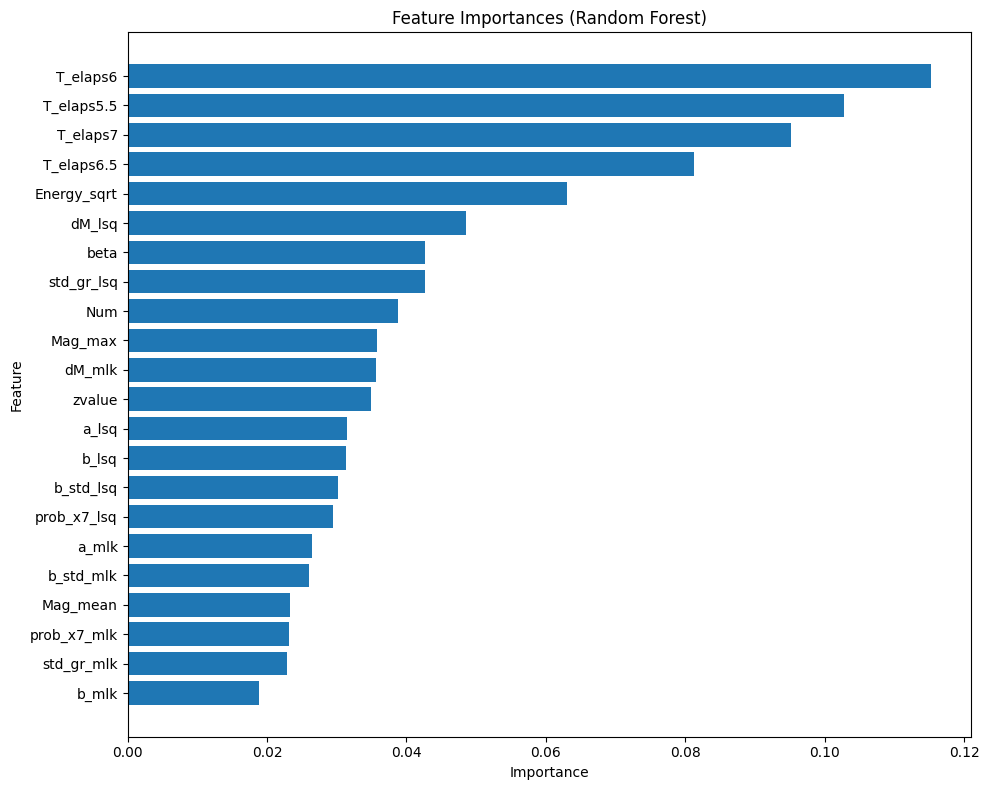

In [10]:
importances = rf.feature_importances_
feature_names = args.feature_cols

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[int(i)] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_names)
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.gca().invert_yaxis()
# plt.savefig(FIG_EXPORT_DIR / 'feature_importances.pdf')
plt.show()

## 8) Compare RF vs Selected `clf_mixer_attnpl_t` (ROC + PR)


Selected mixer checkpoints (8 seeds, selected=None):
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_0/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_1/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_2/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_3/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_4/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_5/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_6/best_model_1.pth
  - /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_7/best_model_1.pth
Loading clf mixer test scores from checkpoint: /root/autodl-tmp/em_eqf/expe

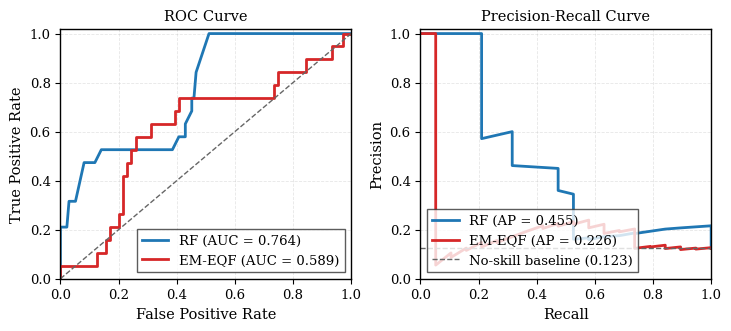

Saved comparison figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_baseline/global/roc_pr_Mf5.5_Twindow180_Tfore90.pdf


In [11]:
# Select clf_mixer_attnpl_t checkpoints by (Mf, Tfore) from RF config.
# Each mapping value can be a seed-run path (e.g., *_seed_1) or a non-seed prefix
# (e.g., tf_90_mf_5p5); all available seed checkpoints are auto-collected.
CLF_MIXER_CKPT_MAP = {
    (4.0, 10): 'experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_10_mf_4p0_seed_0',
    (4.5, 20): 'experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_20_mf_4p5_seed_0',
    (4.5, 30): 'experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_30_mf_4p5_seed_0',
    (5.0, 60): 'experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_60_mf_5p0_seed_0',
    (5.5, 90): 'experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_90_mf_5p5_seed_0',
}

CLF_MIXER_CKPT_NAME = 'best_model_1.pth'
CLF_MIXER_SEED_AGG_METHOD = 'mean'  # 'mean' or 'median'

ckpt_key = (float(args.Mf), int(args.Tfore))
if ckpt_key not in CLF_MIXER_CKPT_MAP:
    available = ', '.join(str(k) for k in sorted(CLF_MIXER_CKPT_MAP.keys()))
    raise KeyError(f'No clf_mixer_attnpl_t checkpoint mapping for Mf/Tfore={ckpt_key}. Available: {available}')

CLF_BATCH_SIZE = 64
CLF_DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

from src.data.preparation import prepare_data
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
import src.utils.viz_analysis as analysis


def load_clf_mixer_test_scores(checkpoint_path: Path):
    check_point = torch.load(checkpoint_path, map_location=CLF_DEVICE, weights_only=False)
    clf_args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(clf_args.model.lower())()
    model = model_builder(clf_args, CLF_DEVICE)
    model, _, _ = load_model_from_checkpoint(model, check_point)
    model.eval()

    clf_args.use_sampler = False
    clf_args.batch_size = CLF_BATCH_SIZE

    base_dir = PROJECT_ROOT / 'data' / clf_args.dataset
    _, _, _, test_loader, _ = prepare_data(args=clf_args, base_dir=str(base_dir))

    y_logits, y_true, _ = analysis.predict_all(
        model,
        test_loader,
        CLF_DEVICE,
        return_X=False,
    )

    logits_np = np.asarray(y_logits, dtype=np.float64)
    y_prob = 1.0 / (1.0 + np.exp(-np.clip(logits_np, -60.0, 60.0)))
    y_true = np.asarray(y_true).astype(int)
    return y_true, y_prob, clf_args


def load_clf_mixer_multi_seed_scores(path_like: str | Path):
    ckpt_paths = resolve_seed_checkpoint_paths(
        path_like,
        project_root=PROJECT_ROOT,
        checkpoints_root=PROJECT_ROOT / 'checkpoints',
        checkpoint_filename=CLF_MIXER_CKPT_NAME,
        selected_seeds=BOOTSTRAP_SELECTED_SEEDS,
    )

    seed_probs = []
    y_true_ref = None
    clf_args_ref = None
    for ckpt_path in ckpt_paths:
        print(f'Loading clf mixer test scores from checkpoint: {ckpt_path}')
        y_true_seed, y_prob_seed, clf_args_seed = load_clf_mixer_test_scores(ckpt_path)
        if y_true_ref is None:
            y_true_ref = y_true_seed
            clf_args_ref = clf_args_seed
        elif not np.array_equal(y_true_ref, y_true_seed):
            raise ValueError(
                f'Label mismatch across seed checkpoints for {path_like}: '
                f'{ckpt_paths[0]} vs {ckpt_path}'
            )
        seed_probs.append(np.asarray(y_prob_seed, dtype=np.float64))

    y_prob_point = np.asarray(np.mean(np.stack(seed_probs, axis=0), axis=0), dtype=np.float64)
    return y_true_ref, y_prob_point, clf_args_ref, ckpt_paths, seed_probs


SELECTED_CLF_MIXER_CKPTS = resolve_seed_checkpoint_paths(
    CLF_MIXER_CKPT_MAP[ckpt_key],
    project_root=PROJECT_ROOT,
    checkpoints_root=PROJECT_ROOT / 'checkpoints',
    checkpoint_filename=CLF_MIXER_CKPT_NAME,
    selected_seeds=BOOTSTRAP_SELECTED_SEEDS,
)
print(f'Selected mixer checkpoints ({len(SELECTED_CLF_MIXER_CKPTS)} seeds, selected={BOOTSTRAP_SELECTED_SEEDS}):')
for p in SELECTED_CLF_MIXER_CKPTS:
    print(f'  - {p}')

y_test_mixer, y_prob_mixer, clf_args, _, mixer_seed_probs = load_clf_mixer_multi_seed_scores(CLF_MIXER_CKPT_MAP[ckpt_key])
print('Mixer seed aggregation method: mean (seed-wise mean metrics)')

fig_dir = FIG_EXPORT_DIR
fig_dir.mkdir(parents=True, exist_ok=True)

if 'rf_seed_probs' not in globals() or rf_seed_probs is None or len(rf_seed_probs) == 0:
    rf_seed_probs = []
    if all(name in globals() for name in ['_fit_or_load_rf_seed_predictions', 'RF_BOOTSTRAP_SEEDS', 'args', 'PROJECT_ROOT', 'prepare_data_rf']):
        try:
            local_base_dir = PROJECT_ROOT / 'data' / args.dataset
            _, _, x_train_rf, _, x_test_rf, y_train_rf, _, y_test_rf = prepare_data_rf(args, local_base_dir)
            y_test_rf = np.asarray(y_test_rf).astype(int)
            if len(y_test_rf) != len(y_test) or not np.array_equal(y_test_rf, np.asarray(y_test).astype(int)):
                raise ValueError('RF labels from prepare_data_rf(args, ...) do not match current y_test.')

            for seed in RF_BOOTSTRAP_SEEDS:
                y_prob_seed, _cache_source = _fit_or_load_rf_seed_predictions(
                    x_train_w=x_train_rf,
                    y_train_w=y_train_rf,
                    x_test_w=x_test_rf,
                    y_test_ref=y_test_rf,
                    mf=float(args.Mf),
                    tfore=int(args.Tfore),
                    seed=int(seed),
                )
                rf_seed_probs.append(np.asarray(y_prob_seed, dtype=np.float64).reshape(-1))

            print(f'[Info] Loaded RF multi-seed predictions for single-window plot: n_seeds={len(rf_seed_probs)}')
        except Exception as exc:
            print(f'[Warn] Failed to build RF multi-seed predictions automatically: {exc}')

    if len(rf_seed_probs) == 0:
        rf_seed_probs = [np.asarray(y_prob, dtype=np.float64)]
        print('[Info] rf_seed_probs fallback: using current RF prediction as single-seed list.')
else:
    rf_seed_probs = [np.asarray(p, dtype=np.float64).reshape(-1) for p in rf_seed_probs]

# RF curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob)
rf_seed_auc = [auc(*roc_curve(y_test, p)[:2]) for p in rf_seed_probs]
rf_seed_ap = [average_precision_score(y_test, p) for p in rf_seed_probs]
rf_roc_auc = float(np.mean(rf_seed_auc))
rf_pr_auc = float(np.mean(rf_seed_ap))

# Mixer curves
mixer_seed_auc = [auc(*roc_curve(y_test_mixer, p)[:2]) for p in mixer_seed_probs]
mixer_seed_ap = [average_precision_score(y_test_mixer, p) for p in mixer_seed_probs]
mixer_roc_auc = float(np.mean(mixer_seed_auc))
mixer_pr_auc = float(np.mean(mixer_seed_ap))

# Use mean seed curve for display
rf_fpr, rf_tpr = roc_curve(y_test, np.asarray(np.mean(np.stack(rf_seed_probs, axis=0), axis=0), dtype=np.float64))[:2]
mixer_fpr, mixer_tpr = roc_curve(y_test_mixer, np.asarray(np.mean(np.stack(mixer_seed_probs, axis=0), axis=0), dtype=np.float64))[:2]
rf_precision, rf_recall = precision_recall_curve(y_test, np.asarray(np.mean(np.stack(rf_seed_probs, axis=0), axis=0), dtype=np.float64))[:2]
mixer_precision, mixer_recall = precision_recall_curve(y_test_mixer, np.asarray(np.mean(np.stack(mixer_seed_probs, axis=0), axis=0), dtype=np.float64))[:2]

same_labels = (
    len(y_test) == len(y_test_mixer)
    and np.array_equal(np.asarray(y_test).astype(int), y_test_mixer)
)
if not same_labels:
    print('[Warn] RF and mixer test labels are not identical in this run. Curves are still plotted, but compare with caution.')

# Publication-style plotting
plot_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10.5,
    'axes.labelsize': 10.5,
    'axes.titlesize': 10.5,
    'legend.fontsize': 9.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'axes.linewidth': 1.0,
}

with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), constrained_layout=True)

    color_rf = '#1f77b4'
    color_em = '#d62728'
    positive_rate = float(np.mean(np.asarray(y_test).astype(int)))

    # (a) ROC
    axes[0].plot(rf_fpr, rf_tpr, color=color_rf, lw=2.0, label=f'RF (AUC = {rf_roc_auc:.3f})')
    axes[0].plot(mixer_fpr, mixer_tpr, color=color_em, lw=2.0, label=f'EM-EQF (AUC = {mixer_roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='0.4', lw=1.0, linestyle='--')
    axes[0].set_xlim(0.0, 1.0)
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].grid(True, linestyle='--', linewidth=0.6, alpha=0.3)
    axes[0].legend(loc='lower right', frameon=True, fancybox=False, edgecolor='0.2')

    # (b) PR
    axes[1].plot(rf_recall, rf_precision, color=color_rf, lw=2.0, label=f'RF (AP = {rf_pr_auc:.3f})')
    axes[1].plot(mixer_recall, mixer_precision, color=color_em, lw=2.0, label=f'EM-EQF (AP = {mixer_pr_auc:.3f})')
    axes[1].hlines(
        y=positive_rate,
        xmin=0.0,
        xmax=1.0,
        colors='0.4',
        linestyles='--',
        linewidth=1.0,
        label=f'No-skill baseline ({positive_rate:.3f})',
    )
    axes[1].set_xlim(0.0, 1.0)
    axes[1].set_ylim(0.0, 1.02)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].grid(True, linestyle='--', linewidth=0.6, alpha=0.3)
    axes[1].legend(loc='lower left', frameon=True, fancybox=False, edgecolor='0.2')
    suffix = f"Mf{args.Mf}_Twindow{args.Twindow}_Tfore{args.Tfore}"
    clf_fig_pdf_path = str(fig_dir / f'roc_pr_{suffix}.pdf')
    fig.savefig(clf_fig_pdf_path, dpi=300)
    plt.show()

print(f'Saved comparison figure (PDF): {clf_fig_pdf_path}')


## 9) Multi-Window RF vs EM-EQF in One Figure (ROC + PR)

Paper-oriented design:
- color encodes window `(Mf, Tfore)`
- line style encodes model (`RF`: dashed, `EM-EQF`: solid)
- one shared figure with two panels: ROC and PR


[Train] positive: 594 | negative: 576 | total: 1170
[Train] positive ratio: 0.508 | negative ratio: 0.492
[Validation] positive: 107 | negative: 39 | total: 146
[Validation] positive ratio: 0.733 | negative ratio: 0.267
[Test] positive: 79 | negative: 68 | total: 147
[Test] positive ratio: 0.537 | negative ratio: 0.463
Loading clf mixer test scores from checkpoint: /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_10_mf_4p0_seed_0/best_model_1.pth
Loading clf mixer test scores from checkpoint: /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_10_mf_4p0_seed_1/best_model_1.pth
Loading clf mixer test scores from checkpoint: /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_10_mf_4p0_seed_2/best_model_1.pth
Loading clf mixer test scores from checkpoint: /root/autodl-tmp/em_eqf/experiments/clf_pre_v1/clf_pre_AZDX_v1/runs/tf_10_mf_4p0_seed_3/best_model_1.pth
Loading clf mixer test scores from checkpoint: /root/autodl-tmp/em_eqf/

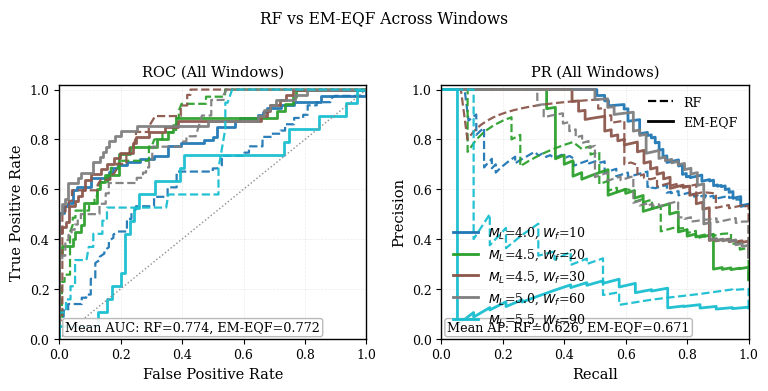

Saved combined multi-window ROC/PR figure: /root/autodl-tmp/em_eqf/notebooks/figs/classifier_baseline/global/rf_vs_em_eqf_multi_window_roc_pr.pdf


In [12]:
from matplotlib.lines import Line2D
from omegaconf import OmegaConf

MULTI_WINDOWS = [
    (4.0, 10),
    (4.5, 20),
    (4.5, 30),
    (5.0, 60),
    (5.5, 90),
]
MULTI_WINDOWS = [w for w in MULTI_WINDOWS if w in CLF_MIXER_CKPT_MAP]


def clone_rf_args_for_window(base_args, mf: float, tfore: int):
    cfg_dict = OmegaConf.to_container(base_args, resolve=True)
    cfg = OmegaConf.create(cfg_dict)
    cfg.Mf = float(mf)
    cfg.Tfore = int(tfore)
    return cfg


def _rf_seed_cache_path(mf: float, tfore: int, seed: int) -> Path:
    return RF_PRED_CACHE_DIR / f'tf_{int(tfore)}_mf_{mf_token(mf)}_seed_{int(seed)}.npz'


def _fit_or_load_rf_seed_predictions(*, x_train_w, y_train_w, x_test_w, y_test_ref, mf, tfore, seed):
    cache_source = 'inference'
    cache_path = _rf_seed_cache_path(mf, tfore, seed)

    if RF_PRED_CACHE_ENABLED and (not RF_FORCE_RETRAIN) and cache_path.exists():
        y_true_cached, y_prob_cached = load_npz_prediction_cache(cache_path)
        if y_true_cached.shape[0] == y_test_ref.shape[0] and np.array_equal(y_true_cached, y_test_ref):
            return y_prob_cached, 'disk'

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=int(seed),
        class_weight='balanced',
    )
    rf_model.fit(x_train_w, y_train_w)
    y_prob_seed = rf_model.predict_proba(x_test_w)[:, 1]

    if RF_PRED_CACHE_ENABLED:
        save_npz_prediction_cache(cache_path, y_true=y_test_ref, y_prob=y_prob_seed)

    return np.asarray(y_prob_seed, dtype=np.float64), cache_source


def evaluate_window_pair(mf: float, tfore: int):
    local_args = clone_rf_args_for_window(args, mf, tfore)
    local_base_dir = PROJECT_ROOT / 'data' / local_args.dataset

    # prepare once per window
    _, _, x_train_w, _, x_test_w, y_train_w, _, y_test_rf = prepare_data_rf(local_args, local_base_dir)
    y_test_rf = np.asarray(y_test_rf).astype(int)

    rf_seed_probs = []
    rf_seed_metrics = []
    rf_cache_stats = {'disk': 0, 'inference': 0}
    for seed in RF_BOOTSTRAP_SEEDS:
        y_prob_seed, cache_source = _fit_or_load_rf_seed_predictions(
            x_train_w=x_train_w,
            y_train_w=y_train_w,
            x_test_w=x_test_w,
            y_test_ref=y_test_rf,
            mf=float(mf),
            tfore=int(tfore),
            seed=int(seed),
        )
        rf_cache_stats[cache_source] = rf_cache_stats.get(cache_source, 0) + 1
        rf_seed_probs.append(np.asarray(y_prob_seed, dtype=np.float64))
        rf_seed_metrics.append(
            classification_metrics(
                y_test_rf,
                y_prob_seed,
                threshold=None,
                optimize_metric='f1',
                apply_sigmoid=False,
            )
        )

    y_prob_rf = np.asarray(np.mean(np.stack(rf_seed_probs, axis=0), axis=0), dtype=np.float64)
    rf_metrics_mean = mean_seed_metrics(rf_seed_metrics)
    rf_seed_auc = [auc(*roc_curve(y_test_rf, p)[:2]) for p in rf_seed_probs]
    rf_seed_ap = [average_precision_score(y_test_rf, p) for p in rf_seed_probs]
    rf_auc = float(np.mean(rf_seed_auc))
    rf_ap = float(np.mean(rf_seed_ap))
    rf_fpr, rf_tpr, _ = roc_curve(y_test_rf, y_prob_rf)
    rf_precision, rf_recall, _ = precision_recall_curve(y_test_rf, y_prob_rf)

    # EM-EQF: seed-wise mean metrics
    ckpt_dir_name = CLF_MIXER_CKPT_MAP[(float(mf), int(tfore))]
    y_test_em, y_prob_em, _, ckpt_paths, em_seed_probs = load_clf_mixer_multi_seed_scores(ckpt_dir_name)
    y_test_em = np.asarray(y_test_em).astype(int)
    em_seed_probs = [np.asarray(p, dtype=np.float64).reshape(-1) for p in em_seed_probs]

    em_seed_metrics = [
        classification_metrics(
            y_test_em,
            p_seed,
            threshold=None,
            optimize_metric='f1',
            apply_sigmoid=False,
        )
        for p_seed in em_seed_probs
    ]
    em_metrics_mean = mean_seed_metrics(em_seed_metrics)
    em_prob_mean = np.asarray(np.mean(np.stack(em_seed_probs, axis=0), axis=0), dtype=np.float64)
    em_seed_auc = [auc(*roc_curve(y_test_em, p)[:2]) for p in em_seed_probs]
    em_seed_ap = [average_precision_score(y_test_em, p) for p in em_seed_probs]
    em_auc = float(np.mean(em_seed_auc))
    em_ap = float(np.mean(em_seed_ap))
    em_fpr, em_tpr, _ = roc_curve(y_test_em, em_prob_mean)
    em_precision, em_recall, _ = precision_recall_curve(y_test_em, em_prob_mean)

    same_labels = (
        len(y_test_rf) == len(y_test_em)
        and np.array_equal(y_test_rf, y_test_em)
    )
    if not same_labels:
        print(f'[Warn] Labels mismatch at window (Mf={mf}, Tfore={tfore}). Compare with caution.')

    return {
        'Mf': float(mf),
        'Tfore': int(tfore),
        'y_test_rf': y_test_rf,
        'y_prob_rf': y_prob_rf,
        'rf_seed_probs': [np.asarray(p, dtype=np.float64) for p in rf_seed_probs],
        'rf_seed_metrics': rf_seed_metrics,
        'rf_metrics_mean': rf_metrics_mean,
        'rf_cache_stats': rf_cache_stats,
        'rf_fpr': rf_fpr,
        'rf_tpr': rf_tpr,
        'rf_recall': rf_recall,
        'rf_precision': rf_precision,
        'rf_auc': float(rf_auc),
        'rf_ap': float(rf_ap),
        'y_test_em': y_test_em,
        'y_prob_em': em_prob_mean,
        'em_seed_probs': em_seed_probs,
        'em_seed_metrics': em_seed_metrics,
        'em_metrics_mean': em_metrics_mean,
        'em_fpr': em_fpr,
        'em_tpr': em_tpr,
        'em_recall': em_recall,
        'em_precision': em_precision,
        'em_auc': float(em_auc),
        'em_ap': float(em_ap),
        'em_seed_ckpts': [str(p) for p in ckpt_paths],
    }


multi_results = [evaluate_window_pair(mf, tf) for (mf, tf) in MULTI_WINDOWS]

for r in multi_results:
    print(
        f"Window Mf={r['Mf']:.1f}, Tfore={r['Tfore']:>3d} | "
        f"RF AUC/AP={r['rf_auc']:.3f}/{r['rf_ap']:.3f} | "
        f"EM-EQF AUC/AP={r['em_auc']:.3f}/{r['em_ap']:.3f} | "
        f"RF cache(disk/infer)={r['rf_cache_stats'].get('disk',0)}/{r['rf_cache_stats'].get('inference',0)}"
    )

mean_rf_auc = float(np.mean([r['rf_auc'] for r in multi_results]))
mean_rf_ap = float(np.mean([r['rf_ap'] for r in multi_results]))
mean_em_auc = float(np.mean([r['em_auc'] for r in multi_results]))
mean_em_ap = float(np.mean([r['em_ap'] for r in multi_results]))

plot_rc_multi = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10.5,
    'axes.labelsize': 10.5,
    'axes.titlesize': 10.5,
    'legend.fontsize': 9.0,
    'xtick.labelsize': 9.0,
    'ytick.labelsize': 9.0,
    'axes.linewidth': 1.0,
}

colors = plt.cm.tab10(np.linspace(0.0, 1.0, len(multi_results)))

with plt.rc_context(plot_rc_multi):
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.8), constrained_layout=False)

    # Curves: same color for same window, dashed/solid for model
    for i, r in enumerate(multi_results):
        c = colors[i]
        axes[0].plot(r['rf_fpr'], r['rf_tpr'], color=c, lw=1.6, linestyle='--', alpha=0.95)
        axes[0].plot(r['em_fpr'], r['em_tpr'], color=c, lw=2.0, linestyle='-', alpha=0.95)

        axes[1].plot(r['rf_recall'], r['rf_precision'], color=c, lw=1.6, linestyle='--', alpha=0.95)
        axes[1].plot(r['em_recall'], r['em_precision'], color=c, lw=2.0, linestyle='-', alpha=0.95)

    axes[0].plot([0, 1], [0, 1], color='0.55', lw=1.0, linestyle=':')
    axes[0].set_xlim(0.0, 1.0)
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC (All Windows)')
    axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

    axes[1].set_xlim(0.0, 1.0)
    axes[1].set_ylim(0.0, 1.02)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('PR (All Windows)')
    axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.25)

    axes[0].text(
        0.02,
        0.03,
        f"Mean AUC: RF={mean_rf_auc:.3f}, EM-EQF={mean_em_auc:.3f}",
        transform=axes[0].transAxes,
        fontsize=9.2,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.7', alpha=0.9),
    )
    axes[1].text(
        0.02,
        0.03,
        f"Mean AP: RF={mean_rf_ap:.3f}, EM-EQF={mean_em_ap:.3f}",
        transform=axes[1].transAxes,
        fontsize=9.2,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.7', alpha=0.9),
    )

    model_handles = [
        Line2D([0], [0], color='black', lw=1.6, linestyle='--', label='RF'),
        Line2D([0], [0], color='black', lw=2.0, linestyle='-', label='EM-EQF'),
    ]
    window_handles = [
        Line2D([0], [0], color=colors[i], lw=2.0, linestyle='-', label=rf'$M_L$={r["Mf"]:.1f}, $W_f$={r["Tfore"]}')
        for i, r in enumerate(multi_results)
    ]

    legend1 = axes[1].legend(handles=model_handles, loc='upper right', frameon=False)
    axes[1].add_artist(legend1)
    axes[1].legend(handles=window_handles, loc='lower left', frameon=False, ncol=1)

    fig.suptitle('RF vs EM-EQF Across Windows', y=1.02, fontsize=11.2)
    fig.tight_layout()

    fig_dir = FIG_EXPORT_DIR
    fig_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = fig_dir / 'rf_vs_em_eqf_multi_window_roc_pr.pdf'
    fig.savefig(pdf_path, bbox_inches='tight')
    plt.show()

print(f'Saved combined multi-window ROC/PR figure: {pdf_path}')


## 10) Separate ROC/PR Figures (2 x 3 Subplots)

If the overlaid curves are too dense, use this faceted layout:
- each row = one window `(Mf, Tfore)`
- left column = ROC, right column = PR
- total subplots = `len(MULTI_WINDOWS) * 2` (can be > 2)


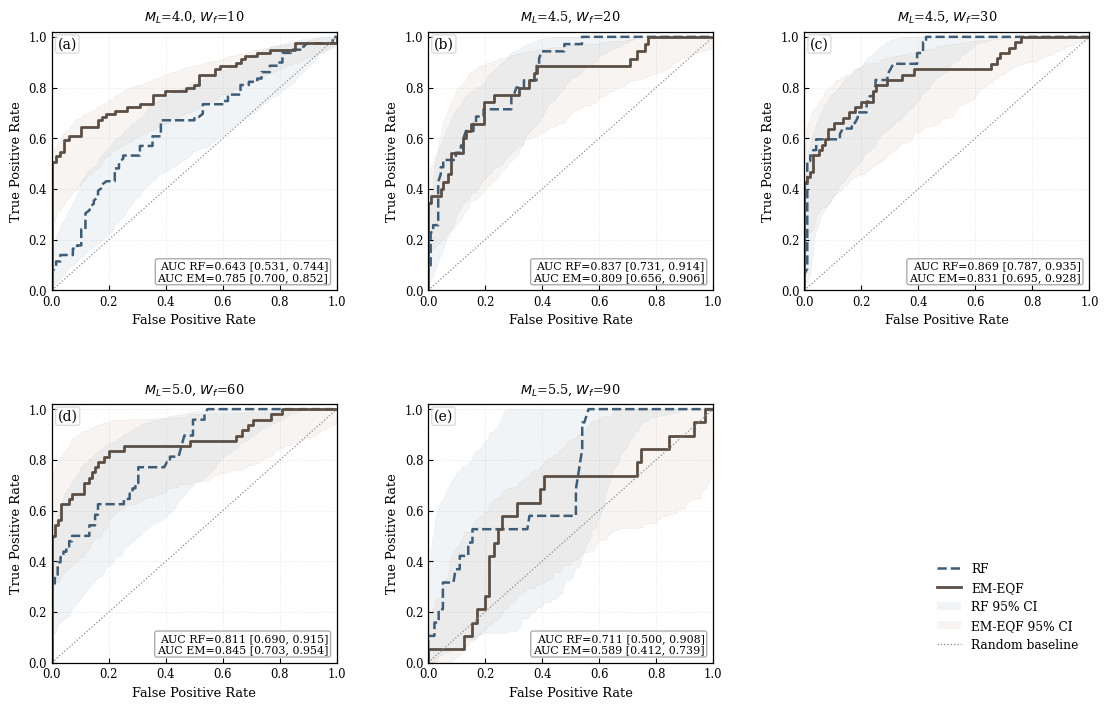

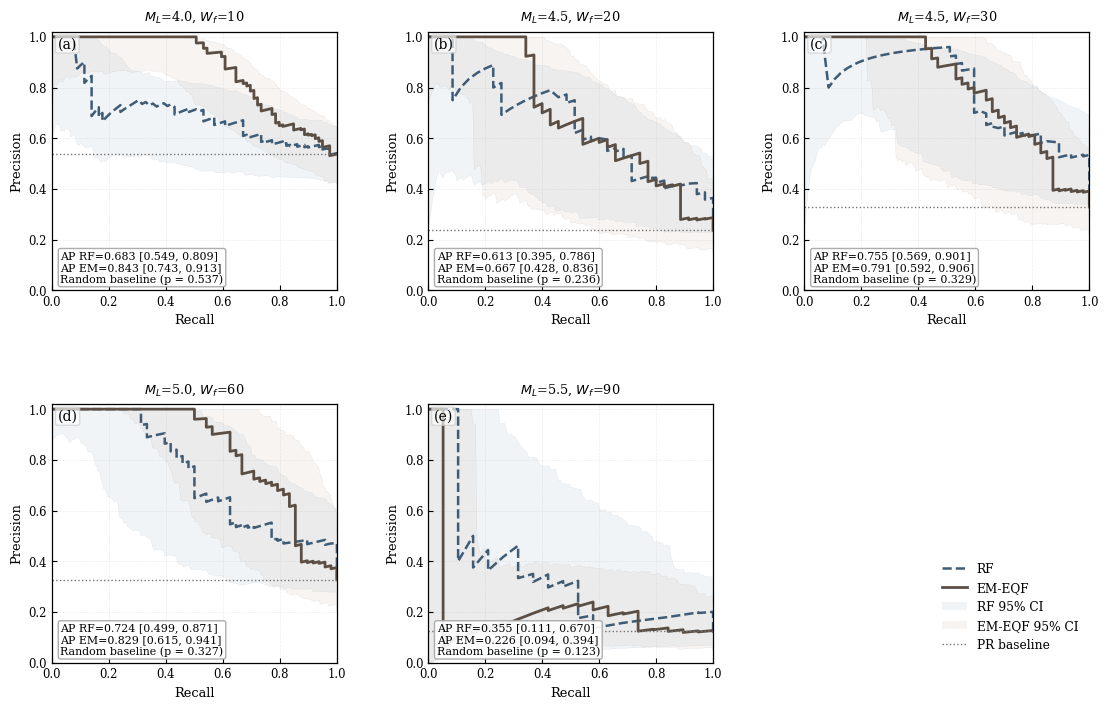

Saved ROC faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_baseline/global/roc_facet_windows_rf_vs_em_eqf_2x3.pdf
Saved PR faceted figure (PDF): /root/autodl-tmp/em_eqf/notebooks/figs/classifier_baseline/global/pr_facet_windows_rf_vs_em_eqf_2x3.pdf


In [13]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Reuse multi_results from Section 9. If Section 9 was not run, build it here.
if 'multi_results' not in globals() or len(multi_results) == 0:
    multi_results = [evaluate_window_pair(mf, tf) for (mf, tf) in MULTI_WINDOWS]


plot_results = list(multi_results)
n_rows, n_cols = 2, 3
max_panels = n_rows * n_cols
if len(plot_results) > max_panels:
    print(f'[Warn] {len(plot_results)} windows provided, only first {max_panels} are plotted.')
    plot_results = plot_results[:max_panels]

panel_labels = [f'({chr(ord("a") + i)})' for i in range(max_panels)]

facet_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9.6,
    'axes.labelsize': 9.4,
    'legend.fontsize': 8.8,
    'xtick.labelsize': 8.4,
    'ytick.labelsize': 8.4,
    'axes.linewidth': 0.9,
}

# Muted colors: keep visual contrast without being too colorful.
color_rf = '#3E5C76'
color_em = '#5B4F45'
ci_color_rf = '#AFC2D6'
ci_color_em = '#D7C4B6'
baseline_color = '0.45'
ci_alpha = 0.18

# Bootstrap setup: switch between IID and block bootstrap.
BOOTSTRAP_SAMPLING_METHOD: SamplingMethod = 'block'  # set to 'block' for block-bootstrap
BOOTSTRAP_PRESET = PairedBootstrapPreset(
    sampling=BOOTSTRAP_SAMPLING_METHOD,
    ci=(2.5, 97.5),
    n_resamples_curve=400,
    n_resamples_metric=800,
    block_size=4,
    circular_block=True,
)


# Pre-compute bootstrap CI once per window.
# Curves and scalar CIs use seed-wise mean.
ci_cache = build_rf_em_window_ci_cache(
    plot_results,
    bootstrap_preset=BOOTSTRAP_PRESET,
    use_hierarchical_seed_sample=USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP,
    seed_aggregation='mean',
    point_estimate_mode=BOOTSTRAP_POINT_ESTIMATE_MODE,
    left_model_name='RF',
    right_model_name='EM-EQF',
)


def plot_roc_grid():
    with plt.rc_context(facet_rc):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.4, 7.6), squeeze=False, constrained_layout=False)
        axes_flat = axes.ravel()

        for i, ax in enumerate(axes_flat):
            if i >= len(plot_results):
                ax.axis('off')
                continue

            r = plot_results[i]
            grid_roc, rf_roc_lo, rf_roc_hi = ci_cache[i]['roc_rf']
            _, em_roc_lo, em_roc_hi = ci_cache[i]['roc_em']
            auc_rf_lo, auc_rf_hi = ci_cache[i]['auc_ci_rf']
            auc_em_lo, auc_em_hi = ci_cache[i]['auc_ci_em']

            ax.fill_between(grid_roc, rf_roc_lo, rf_roc_hi, color=ci_color_rf, alpha=ci_alpha, edgecolor=color_rf, linewidth=0.2)
            ax.fill_between(grid_roc, em_roc_lo, em_roc_hi, color=ci_color_em, alpha=ci_alpha, edgecolor=color_em, linewidth=0.2)
            ax.plot(r['rf_fpr'], r['rf_tpr'], color=color_rf, lw=1.8, linestyle='--')
            ax.plot(r['em_fpr'], r['em_tpr'], color=color_em, lw=2.0, linestyle='-')
            ax.plot([0, 1], [0, 1], color='0.55', lw=0.9, linestyle=':')
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.02)
            ax.grid(True, linestyle='--', linewidth=0.45, alpha=0.25)
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.tick_params(direction='in', length=3.3, width=0.8)

            ax.text(
                0.02,
                0.98,
                panel_labels[i],
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=10.1,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='0.8', alpha=0.65),
            )
            ax.set_title(rf'$M_L$={r["Mf"]:.1f}, $W_f$={r["Tfore"]}', fontsize=9.3, pad=8)
            ax.text(
                0.97,
                0.03,
                f'AUC RF={r["rf_auc"]:.3f} [{auc_rf_lo:.3f}, {auc_rf_hi:.3f}]\n'
                f'AUC EM={r["em_auc"]:.3f} [{auc_em_lo:.3f}, {auc_em_hi:.3f}]',
                transform=ax.transAxes,
                fontsize=7.9,
                ha='right',
                va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.65', alpha=0.92),
            )

        legend_handles = [
            Line2D([0], [0], color=color_rf, lw=1.8, linestyle='--', label='RF'),
            Line2D([0], [0], color=color_em, lw=2.0, linestyle='-', label='EM-EQF'),
            Patch(facecolor=ci_color_rf, edgecolor='none', alpha=ci_alpha, label='RF 95% CI'),
            Patch(facecolor=ci_color_em, edgecolor='none', alpha=ci_alpha, label='EM-EQF 95% CI'),
            Line2D([0], [0], color='0.55', lw=0.9, linestyle=':', label='Random baseline'),
        ]
        empty_axes = [axes_flat[j] for j in range(len(plot_results), len(axes_flat))]
        if len(empty_axes) > 0:
            legend_ax = empty_axes[-1]
            legend_ax.axis('off')
            legend_ax.legend(handles=legend_handles, loc='lower right', frameon=False)
        else:
            fig.legend(handles=legend_handles, loc='lower right', frameon=False)
        fig.subplots_adjust(top=0.91, bottom=0.08, left=0.07, right=0.98, hspace=0.44, wspace=0.32)

        fig_dir = FIG_EXPORT_DIR
        fig_dir.mkdir(parents=True, exist_ok=True)
        roc_pdf_path = str(fig_dir / 'roc_facet_windows_rf_vs_em_eqf_2x3.pdf')
        plt.savefig(roc_pdf_path, bbox_inches='tight')
        plt.show()

    return roc_pdf_path


def plot_pr_grid():
    with plt.rc_context(facet_rc):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(11.4, 7.6), squeeze=False, constrained_layout=False)
        axes_flat = axes.ravel()

        for i, ax in enumerate(axes_flat):
            if i >= len(plot_results):
                ax.axis('off')
                continue

            r = plot_results[i]
            pos_rate = float(np.mean(np.asarray(r['y_test_rf']).astype(int)))
            grid_pr, rf_pr_lo, rf_pr_hi = ci_cache[i]['pr_rf']
            _, em_pr_lo, em_pr_hi = ci_cache[i]['pr_em']
            ap_rf_lo, ap_rf_hi = ci_cache[i]['ap_ci_rf']
            ap_em_lo, ap_em_hi = ci_cache[i]['ap_ci_em']

            ax.fill_between(grid_pr, rf_pr_lo, rf_pr_hi, color=ci_color_rf, alpha=ci_alpha, edgecolor=color_rf, linewidth=0.2)
            ax.fill_between(grid_pr, em_pr_lo, em_pr_hi, color=ci_color_em, alpha=ci_alpha, edgecolor=color_em, linewidth=0.2)
            ax.plot(r['rf_recall'], r['rf_precision'], color=color_rf, lw=1.8, linestyle='--')
            ax.plot(r['em_recall'], r['em_precision'], color=color_em, lw=2.0, linestyle='-')
            ax.hlines(pos_rate, 0.0, 1.0, colors=baseline_color, linestyles=':', linewidth=1.0)
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.02)
            ax.grid(True, linestyle='--', linewidth=0.45, alpha=0.25)
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.tick_params(direction='in', length=3.3, width=0.8)

            ax.text(
                0.02,
                0.98,
                panel_labels[i],
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=10.1,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='0.8', alpha=0.65),
            )
            ax.set_title(rf'$M_L$={r["Mf"]:.1f}, $W_f$={r["Tfore"]}', fontsize=9.3, pad=8)
            ax.text(
                0.03,
                0.03,
                f'AP RF={r["rf_ap"]:.3f} [{ap_rf_lo:.3f}, {ap_rf_hi:.3f}]\n'
                f'AP EM={r["em_ap"]:.3f} [{ap_em_lo:.3f}, {ap_em_hi:.3f}]\n'
                f'Random baseline (p = {pos_rate:.3f})',
                transform=ax.transAxes,
                fontsize=7.9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='0.65', alpha=0.92),
            )

        legend_handles = [
            Line2D([0], [0], color=color_rf, lw=1.8, linestyle='--', label='RF'),
            Line2D([0], [0], color=color_em, lw=2.0, linestyle='-', label='EM-EQF'),
            Patch(facecolor=ci_color_rf, edgecolor='none', alpha=ci_alpha, label='RF 95% CI'),
            Patch(facecolor=ci_color_em, edgecolor='none', alpha=ci_alpha, label='EM-EQF 95% CI'),
            Line2D([0], [0], color=baseline_color, lw=1.0, linestyle=':', label='PR baseline'),
        ]
        empty_axes = [axes_flat[j] for j in range(len(plot_results), len(axes_flat))]
        if len(empty_axes) > 0:
            legend_ax = empty_axes[-1]
            legend_ax.axis('off')
            legend_ax.legend(handles=legend_handles, loc='lower right', frameon=False)
        else:
            fig.legend(handles=legend_handles, loc='lower right', frameon=False)
        fig.subplots_adjust(top=0.91, bottom=0.08, left=0.07, right=0.98, hspace=0.44, wspace=0.32)

        fig_dir = FIG_EXPORT_DIR
        fig_dir.mkdir(parents=True, exist_ok=True)
        pr_pdf_path = str(fig_dir / 'pr_facet_windows_rf_vs_em_eqf_2x3.pdf')
        plt.savefig(pr_pdf_path, bbox_inches='tight')
        plt.show()

    return pr_pdf_path


roc_pdf_path = plot_roc_grid()
pr_pdf_path = plot_pr_grid()
print(f'Saved ROC faceted figure (PDF): {roc_pdf_path}')
print(f'Saved PR faceted figure (PDF): {pr_pdf_path}')



## 11) Export Metrics (AUC Bootstrap Only)

Export per-window metrics for **all compared models** with paired bootstrap confidence intervals, and save CSV/JSON artifacts.


In [14]:
# Reuse multi_results from Section 9. If Section 9 was not run, build it here.
if 'multi_results' not in globals() or len(multi_results) == 0:
    multi_results = [evaluate_window_pair(mf, tf) for (mf, tf) in MULTI_WINDOWS]

# Reuse the preset from Section 10 when available.
if 'BOOTSTRAP_PRESET' in globals():
    export_bootstrap_preset = BOOTSTRAP_PRESET
else:
    export_bootstrap_preset = PairedBootstrapPreset(
        sampling='block',
        ci=(2.5, 97.5),
        n_resamples_curve=400,
        n_resamples_metric=800,
        block_size=4,
        circular_block=True,
    )

EXPORT_DIR = METRIC_EXPORT_DIR
EXPORT_STEM = 'clf_ci'
ROUND_DECIMALS = 4
SORT_EXPORT_BY = ('Mf', 'Tfore', 'model')
SORT_DELTA_BY = ('Mf', 'Tfore', 'comparison')
THRESHOLD_OPTIMIZE_METRIC = 'f1'

if EXPORT_POINT_METRIC_MODE != 'mean_seed_metrics':
    raise ValueError(f"Unsupported EXPORT_POINT_METRIC_MODE: {EXPORT_POINT_METRIC_MODE!r}. Expected 'mean_seed_metrics'.")

def _r4(value):
    return round_optional(value, ROUND_DECIMALS)

export_artifacts = run_classification_bootstrap_export_pipeline(
    multi_results=multi_results,
    bootstrap_preset=export_bootstrap_preset,
    round_fn=_r4,
    threshold_optimize_metric=THRESHOLD_OPTIMIZE_METRIC,
    use_hierarchical_seed_sample=USE_HIERARCHICAL_SEED_SAMPLE_BOOTSTRAP,
    export_dir=EXPORT_DIR,
    export_stem=EXPORT_STEM,
    export_label='AZDX_b',
    round_decimals=ROUND_DECIMALS,
    seed_aggregation='mean',
    point_estimate_mode=BOOTSTRAP_POINT_ESTIMATE_MODE,
    baseline_model='EM-EQF',
    sort_export_by=SORT_EXPORT_BY,
    sort_delta_by=SORT_DELTA_BY,
    window_model_rows_getter=lambda r: {
        'RF': {
            'metrics': r['rf_metrics_mean'],
            'y_true': r['y_test_rf'],
            'y_prob': r['y_prob_rf'],
            'seed_probs': r['rf_seed_probs'],
            'seed_metrics': r.get('rf_seed_metrics', []),
        },
        'EM-EQF': {
            'metrics': r['em_metrics_mean'],
            'y_true': r['y_test_em'],
            'y_prob': r['y_prob_em'],
            'seed_probs': r['em_seed_probs'],
            'seed_metrics': r.get('em_seed_metrics', []),
        },
    },
    metadata={
        'dataset': str(args.dataset),
        'rf_multi_seeds': [int(s) for s in RF_BOOTSTRAP_SEEDS],
        'bootstrap_selected_seeds': (
            [int(s) for s in BOOTSTRAP_SELECTED_SEEDS]
            if BOOTSTRAP_SELECTED_SEEDS is not None
            else None
        ),
        'rf_curve_seed_aggregation': 'seed_wise_mean',
        'export_point_metric_mode': 'mean_seed_metrics',
        'point_metric_mode': 'seed_mean',
        'seedwise_mean_metrics': True,
    },
)

render_classification_bootstrap_export(export_artifacts)
summary_by_model = export_artifacts.summary_by_model
summary_by_model


Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/global/clf_ci_long_AZDX_b.csv
Bootstrap pairwise delta CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/global/clf_ci_pairwise_delta_AZDX_b.csv
Bootstrap JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/classifier_baseline/global/clf_ci_long_AZDX_b.json
Exported rows: metrics=10, deltas=5


,Mf,Tfore,model,auc,auc_point_estimate_std,ap,ap_point_estimate_std,auc_ci_low,auc_ci_high,ap_ci_low,ap_ci_high
0,4.0,10,EM-EQF,0.7846,0.0477,0.8426,0.0658,0.7031,0.8526,0.7557,0.9126
1,4.0,10,RF,0.6428,0.0151,0.6834,0.0159,0.5304,0.7366,0.5502,0.8147
2,4.5,20,EM-EQF,0.8085,0.0373,0.6673,0.0321,0.6678,0.9140,0.4262,0.8403
3,4.5,20,RF,0.8366,0.0198,0.6127,0.0718,0.7300,0.9121,0.3857,0.7951
4,4.5,30,EM-EQF,0.8310,0.0291,0.7907,0.0234,0.6976,0.9269,0.5577,0.9112
5,4.5,30,RF,0.8693,0.0156,0.7550,0.0308,0.7810,0.9354,0.5502,0.8929
6,5.0,60,EM-EQF,0.8452,0.0401,0.8288,0.0247,0.7031,0.9622,0.6843,0.9422
7,5.0,60,RF,0.8111,0.0372,0.7235,0.0353,0.6867,0.9212,0.5380,0.8805
8,5.5,90,EM-EQF,0.5894,0.1790,0.2262,0.0846,0.4051,0.7502,0.0955,0.4011
9,5.5,90,RF,0.7111,0.0301,0.3552,0.0738,0.4838,0.9198,0.1047,0.6580


{'EM-EQF': {'mean_threshold': 0.482,
  'mean_f1': 0.62,
  'mean_recall': 0.7283,
  'mean_precision': 0.5999,
  'mean_r': 0.4621,
  'mean_auc': 0.7717,
  'std_auc': 0.1045,
  'mean_ap': 0.6711,
  'std_ap': 0.2581,
  'num_windows': 5},
 'RF': {'mean_threshold': 0.4275,
  'mean_f1': 0.6116,
  'mean_recall': 0.7704,
  'mean_precision': 0.5514,
  'mean_r': 0.4099,
  'mean_auc': 0.7742,
  'std_auc': 0.0943,
  'mean_ap': 0.626,
  'std_ap': 0.1604,
  'num_windows': 5}}